## Validate entrenchment sites using raw count data
This notebook attempts to validate the findings of entrenchment of specific sites between v families or v genes using DASM using raw counts.
rates_analysis_productive_non_productive was lacking many entrenched data points because they have barely been observed in the non productive data.
To deal with this limitation, we ran a similar analysis, but instead of calculating the expected counts from the data, we will take it use thrifty to calculate, and compare to the observed counts in the productive data. 
We compare counts directly and not rates because the pcp dataset is the same, and thus has the same branch lengths and they will cancel each other out.


For productive data, observed counts (code duplicated from rates_analysis_productive_non_productive):
- Counted as mutations away from the germline amino acid for the v gene. Thus, rates are only calculated for v-gene encoded sites. 
- Calculated per v_family+site+parent_aa+child_aa, to compare to DASM.

For expected counts:
- we run thrifty on the same dataset, so branch lengths will be the same as the productive counts and counts can be compared directly.
- Thrifty gives out a rate for any substitution and a conditional substitution probability (csp). I use branch length (which can be synonymous mutation frequncy or total mutation frequency, total mutation frequency seem to work better in this case) to calculate the general substation probability from the rate, and multiply by the csp to get the substitution probability per target amino acid for every branch/pcp. I then sum over those per v_family+site+parent_aa+target_aa to get the expected counts. 


The calculation is performed on pcps and relies on previous code:
- For observed counts, site_sub_probs_df from OEPlotter is utilized - probabilities are not used of course, only the occurences of mutations on a pcp.
- For expected counts, we adapted code from dnsm-experiments-1/dnsmex/neutral_mutability.py. That code provides the mutability per a constant branch length, and here we added the option for a separate branch length calculation - synonymous mutation frequency or total mutaiton frequency.

Entrenched sites, aas and v families are loaded from _output/entrenchment_analysis made in vj_families_dasm.

Results:
- Count ratios calculated align nicely with DASM.
- Entrenched sites and substitutions also align nicely, most of them are still under purifying selection but some are closer to neutral. Need to discuss this in the paper. Not all substitutions can be validated with this approach, but most of them can.
- Synonymous mutations cluster around neutral with a more prominent purifying selection side. This could be because (1) not all synonymous mutations are truly neutral and can effect mRNA stability, codon usag and more. and (2) because when a mutation is very rare thrifty did not have a log of training data for it (or any) and so it could be oversestimating its occurence.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from utils import sort_antibody_sites, add_germline_information, load_and_process_dnsm_data, load_and_process_dasm_data, load_entrenched_sites

from dnsmex.neutral_mutability import CachedNeutralMutabilityDataset

from rates_analysis_util import (
    compare_mutation_rates_on_different_backgrounds_for_all_sites,
    add_mutation_counts_per_branch_for_branch_length,
    plot_dasm_vs_rates_comparison,
    plot_rates_pairwise_analysis,
)

figures_dir = 'figures/'

In [2]:
#DATASET = 'v1rodriguez'
DATASET = 'v1jaffe'
#DATASET = "v1tang"

numbering_scheme = 'chothia'

BRANCH_LENGTH_METHOD = 'mutation_frequency' 
#BRANCH_LENGTH_METHOD = 'synonymous_frequency'

#BRANCH_LENGTH_SCALE_FACTOR = 1.0
BRANCH_LENGTH_SCALE_FACTOR = 1.74


# entrenchment analysis comparison parameters
dasm_compare_dataset_name = "v1rodriguez"
dasm_compare_model_name = "dasm_4m-v1jaffeCC+v1tangCC-joint"


In [3]:
## load and prepare data for **observed** mutation counts

In [4]:
## calculate observed mutation counts
## branch length method doesn't actually matter here because we are using the ratio of observed to expected counts (same pcp dataset, so same branch lengths will cancel out anyway)
## LEAF FILTERING: Leaves are excluded via remove_leaves=True in compare_mutation_rates_on_different_backgrounds_for_all_sites

output_dirs = ['_ignore/observed_counts_from_productive']
for dir in output_dirs:
    if not os.path.exists(dir):
        os.mkdir(dir)

branch_length_method = 'total_mutation_freq_branch'

output_base_path = f'_ignore/observed_counts_from_productive/observed_mutation_rates_{DATASET}_bl_{branch_length_method}_{numbering_scheme}'

# load substitution occurences and sum counts, DNSM outputs aren't used here
site_sub_probs_df_germline_total, total_pcp_df = load_and_process_dnsm_data(model_name = "dnsm_1m-v1jaffe+v1tang-joint", dataset_name=DATASET, numbering_scheme=numbering_scheme)
site_sub_probs_df_germline_total = add_mutation_counts_per_branch_for_branch_length(site_sub_probs_df_germline_total)
compare_mutation_rates_on_different_backgrounds_for_all_sites(site_sub_probs_df_germline_total, output_base_path, branch_length_method=branch_length_method, remove_leaves=True, pcp_df=total_pcp_df)

observed_aa_df = pd.read_csv(f'{output_base_path}_per_aa_mutation_rates.csv', dtype={'site':str})
observed_aa_df = observed_aa_df.rename(columns={
    'mutation_acquired': 'observed_counts',
    'mutation_acquired_adjusted': 'observed_counts_adjusted',
    'mutcount_length': 'mutcount_length_observed'
}).drop(columns=['rate_mutcount', 'rate_mutcount_adjusted'])
observed_aa_df

Removing leaf nodes from the analysis


Processing 147 sites...
Processing site 1/147: site 1


Processing site 11/147: site 11


Processing site 21/147: site 21


Processing site 31/147: site 31


...

No data for V family IGHV1 at site 109
No data for V family IGHV3 at site 109
No data for V family IGHV4 at site 109
No data for V family IGHV1 at site 110
No data for V family IGHV3 at site 110
No data for V family IGHV4 at site 110


No data for V family IGHV1 at site 111
No data for V family IGHV3 at site 111
No data for V family IGHV4 at site 111


No data for V family IGHV1 at site 112
No data for V family IGHV3 at site 112
No data for V family IGHV4 at site 112
No data for V family IGHV1 at site 113
No data for V family IGHV3 at site 113
No data for V family IGHV4 at site 113
Converting results to DataFrames...
Saving overall results to _ignore/observed_counts_from_productive/observed_mutation_rates_v1jaffe_bl_total_mutation_freq_branch_chothia_overall_mutation_rates.csv
Overall results: 297 rows saved
Saving per-amino acid results to _ignore/observed_counts_from_productive/observed_mutation_rates_v1jaffe_bl_total_mutation_freq_branch_chothia_per_aa_mutation_rates.csv


Per-AA results: 10032 rows saved
Saving per-codon results to _ignore/observed_counts_from_productive/observed_mutation_rates_v1jaffe_bl_total_mutation_freq_branch_chothia_per_codon_mutation_rates.csv
Per-codon results: 6156 rows saved


,v_family,site,parent_aa,child_aa,mutcount_length_observed,observed_counts,observed_counts_adjusted
0,IGHV1,1,Q,A,109.241070,0,0.5
1,IGHV1,1,Q,C,109.241070,0,0.5
2,IGHV1,1,Q,D,109.241070,0,0.5
3,IGHV1,1,Q,E,109.241070,4,4.5
4,IGHV1,1,Q,F,109.241070,0,0.5
...,...,...,...,...,...,...,...
10027,IGHV4,94,R,S,166.806461,12,12.5
10028,IGHV4,94,R,T,166.806461,42,42.5
10029,IGHV4,94,R,V,166.806461,0,0.5
10030,IGHV4,94,R,W,166.806461,0,0.5


In [5]:
# Assert that observed counts from rates calculation file match direct computation from site_sub_probs_df
# This validates that observed counts are computed consistently with expected counts

pcp_indices_non_leaf = total_pcp_df[~total_pcp_df['child_is_leaf']].index
observed_aa_df_test = site_sub_probs_df_germline_total[
      (site_sub_probs_df_germline_total.is_germline_codon == True) &
      (site_sub_probs_df_germline_total.pcp_index.isin(pcp_indices_non_leaf)) &
      (site_sub_probs_df_germline_total.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4']))      
  ].groupby(['site', 'parent_aa', 'v_family', 'child_aa']).mutation.sum().reset_index()


observed_aa_df_test = observed_aa_df_test[
    (observed_aa_df_test.mutation > 0)
].rename(columns={'mutation':'observed_counts'})[
    ['v_family', 'site', 'parent_aa', 'child_aa','observed_counts']
].sort_values(['v_family', 'site', 'parent_aa', 'child_aa']).reset_index(drop=True)

observed_from_rates = observed_aa_df[
    (observed_aa_df.observed_counts > 0)
][['v_family', 'site', 'parent_aa', 'child_aa','observed_counts']].sort_values(
    ['v_family', 'site', 'parent_aa', 'child_aa']
).reset_index(drop=True)

assert observed_aa_df_test.equals(observed_from_rates), \
    "Observed counts from direct computation don't match cached file!"

In [6]:
# load thrifty neutral model **expected** mutation counts
# Updated to use new CachedNeutralMutabilityDataset from dnsm-experiments-1

# Create cached dataset with new API
# branch_length_mode: 'mutation_frequency' (was 'from_total_mutations')
#                     'synonymous_frequency' (was 'from_synonymous_mutations')
neutral_probabilties = CachedNeutralMutabilityDataset(
    dataset_nickname=DATASET,
    branch_length_mode=BRANCH_LENGTH_METHOD,
    branch_length_scale_factor=BRANCH_LENGTH_SCALE_FACTOR,
    numbering_scheme=numbering_scheme,
)

# add germline information to all dataframes
neutral_probabilties.aa_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.aa_neutral_df, numbering_scheme=numbering_scheme)
neutral_probabilties.aa_to_any_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.aa_to_any_neutral_df, numbering_scheme=numbering_scheme)
neutral_probabilties.codon_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.codon_neutral_df, numbering_scheme=numbering_scheme)
neutral_probabilties.codon_to_any_neutral_df = add_germline_information(neutral_probabilties.pcp_df, neutral_probabilties.codon_to_any_neutral_df, numbering_scheme=numbering_scheme)

# LEAF FILTERING for expected data: Manually filter out leaf nodes to match observed data
# (observed uses remove_leaves=True in compare_mutation_rates_on_different_backgrounds_for_all_sites)
pcp_indices_non_leaf = neutral_probabilties.pcp_df[~neutral_probabilties.pcp_df['child_is_leaf']].index
# probabilities sum to counts
expected_aa_df = neutral_probabilties.aa_neutral_df[
      (neutral_probabilties.aa_neutral_df.is_germline_codon == True) &
      (neutral_probabilties.aa_neutral_df.pcp_index.isin(pcp_indices_non_leaf))
  ].groupby(['site', 'current_aa', 'v_family', 'transition_aa']).substitution_probability.sum().reset_index()
expected_aa_df

Loading NeutralMutabilityDataset data from gzip cache...


✓ Loaded from gzip cache:
  - Nucleotide DataFrame: 333,641,184 rows
  - Amino Acid DataFrame: 195,090,853 rows
  - Amino Acid to Any DataFrame: 27,803,432 rows
  - Codon DataFrame: 250,230,888 rows
  - Codon to Any DataFrame: 27,803,432 rows
  - PCP DataFrame: 228,789 rows


,site,current_aa,v_family,transition_aa,substitution_probability
0,1,E,IGHV1,*,0.156388
1,1,E,IGHV1,A,0.115736
2,1,E,IGHV1,D,0.357210
3,1,E,IGHV1,E,0.304171
4,1,E,IGHV1,G,0.208707
...,...,...,...,...,...
6970,94,T,IGHV3,K,8.544498
6971,94,T,IGHV3,P,12.426252
6972,94,T,IGHV3,R,11.211837
6973,94,T,IGHV3,S,10.875886


<Axes: >

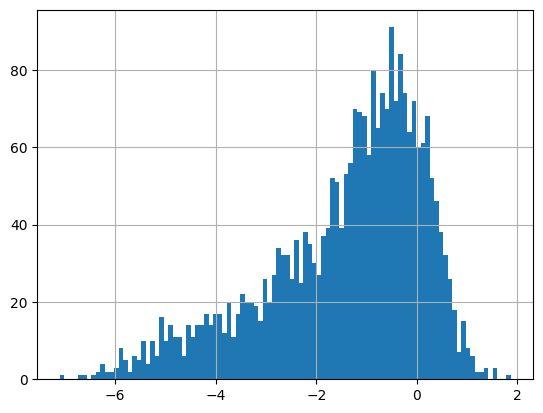

In [7]:
# merge observed and expected counts - ratio should be the selection factor.

merge_counts = pd.merge(expected_aa_df.rename(columns={'current_aa':'parent_aa', 'transition_aa':'child_aa', 'substitution_probability':'expected_counts'}), observed_aa_df, on=['v_family', 'site', 'parent_aa', 'child_aa'])

# Use adjusted counts (with pseudocount already applied)
# For expected counts from Thrifty, we add pseudocount here since Thrifty doesn't have it built in
pseudocount = 0.5
merge_counts['ratio'] = merge_counts['observed_counts_adjusted'] / (merge_counts['expected_counts'] + pseudocount)
merge_counts['log_ratio'] = np.log(merge_counts['ratio'])

merge_counts[merge_counts.expected_counts >= 5].log_ratio.hist(bins=100)

## load entrenches sites identified by DASM analysis

We separate sites into two types of evolutionarily constrained sites:
- Within v family entrenched sites
- Between v-family entrenched sites

Here we plot both types together, since we just want to make sure our entrenched sites are not edge cases with low counts.

In [8]:
# Load entrenched sites using consolidated function from utils
entrenched_sites, entrenched_sites_aas, pairwise_df_dict, SITE_COLOR_MAP, within_dfs, vs_dfs = load_entrenched_sites(numbering_scheme)

print(f"Loaded {len(entrenched_sites)} entrenched sites")
print(f"Loaded {len(entrenched_sites_aas)} entrenched site-aa pairs")
print(f"Created color mapping for {len(SITE_COLOR_MAP)} sites")

Loaded 44 entrenched sites
Loaded 113 entrenched site-aa pairs
Created color mapping for 18 sites


In [9]:
pairwise_df_dict.keys()

dict_keys(['IGHV3_vs_IGHV4', 'IGHV1_vs_IGHV4', 'IGHV1_vs_IGHV3', 'within_IGHV3', 'within_IGHV1', 'within_IGHV4'])

## Compare rate ratio to DASM

In [10]:
### compare to DASM


_, _, aa_site_subs_selection_df_germline = load_and_process_dasm_data(model_name=dasm_compare_model_name, dataset_name=dasm_compare_dataset_name, numbering_scheme=numbering_scheme)

dasm_summarized = aa_site_subs_selection_df_germline[(aa_site_subs_selection_df_germline.is_germline_aa == True) & (aa_site_subs_selection_df_germline.one_mutation_away == True)].groupby(['v_family', 'site', 'parent_aa', 'selection_factor_target_aa']).selection_factor.median().reset_index()


Adding one_mutation_away column (vectorized)...


Plotting 113 entrenched points


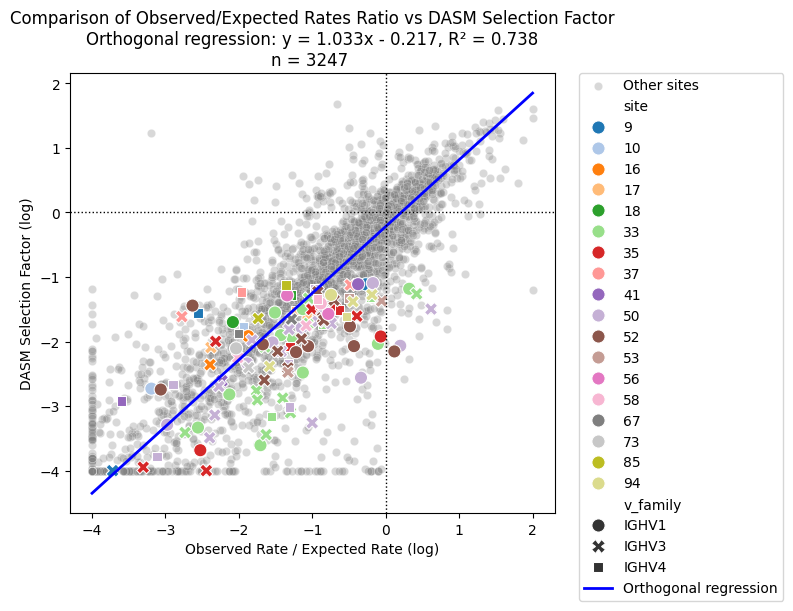

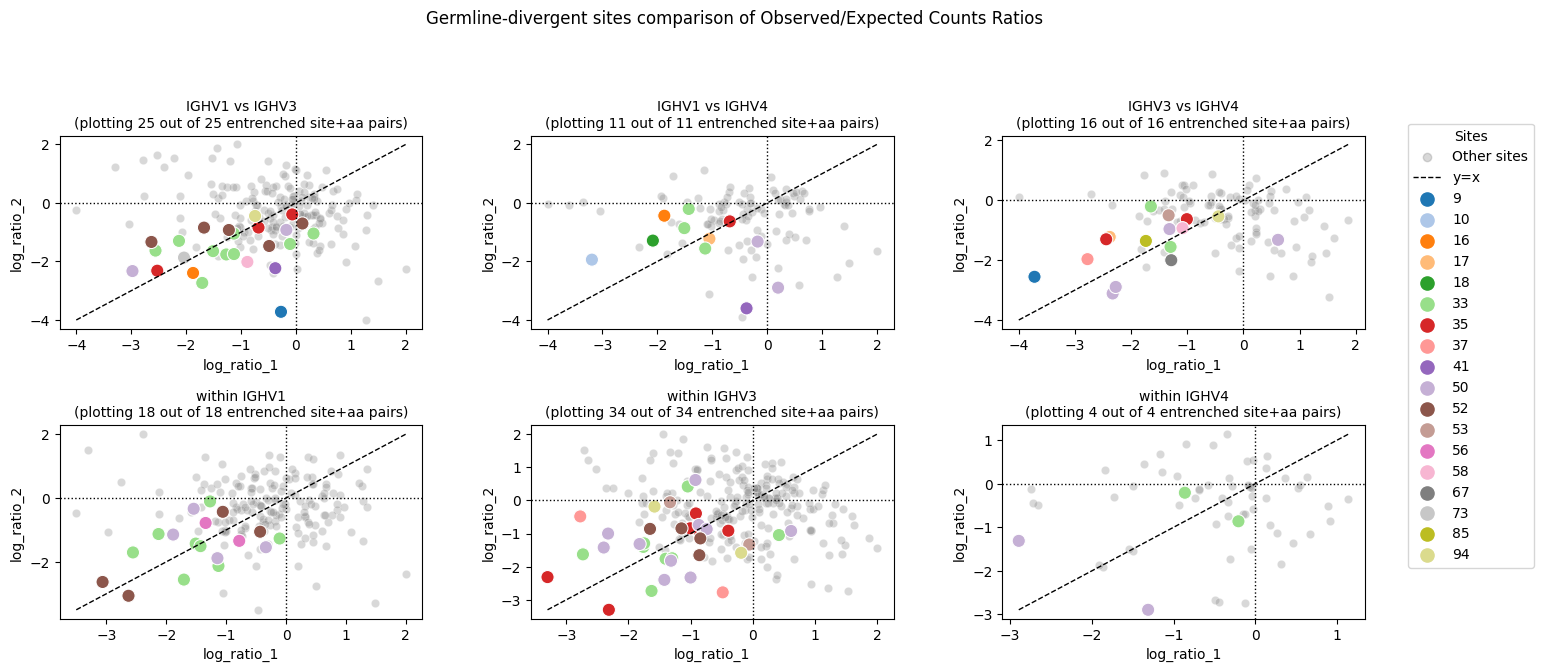

In [11]:
## show unfiltered data

compare_dasm_rates = pd.merge(merge_counts, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))
compare_dasm_rates['log_selection_factor'] = np.log(compare_dasm_rates['selection_factor'])

# clip very low and very high values
compare_dasm_rates['log_selection_factor'] = compare_dasm_rates['log_selection_factor'].clip(lower=-4, upper=2)
compare_dasm_rates['log_ratio'] = compare_dasm_rates['log_ratio'].clip(lower=-4, upper=2)

plot_dasm_vs_rates_comparison(compare_dasm_rates, entrenched_sites_aas, SITE_COLOR_MAP)
plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict, SITE_COLOR_MAP)

Plotting 87 entrenched points
The following entrenched points were not found in the comparison data:
     site v_family parent_aa child_aa
172    16    IGHV4         G        A
632    33    IGHV1         D        A
635    33    IGHV1         D        Y
642    33    IGHV1         S        Y
643    33    IGHV1         T        A
656    33    IGHV3         D        A
658    33    IGHV3         D        Y
677    33    IGHV3         T        A
690    33    IGHV4         S        Y
730    35    IGHV1         N        D
742    35    IGHV3         D        H
817    37    IGHV4         V        F
909    41    IGHV1         R        P
1110   50    IGHV1         G        W
1117   50    IGHV1         L        R
1119   50    IGHV1         R        S
1120   50    IGHV1         R        W
1144   50    IGHV3         L        R
1227   52    IGHV1         D        G
1228   52    IGHV1         D        V
1229   52    IGHV1         D        Y
1249   52    IGHV1         V        D
1250   52    IGHV1       

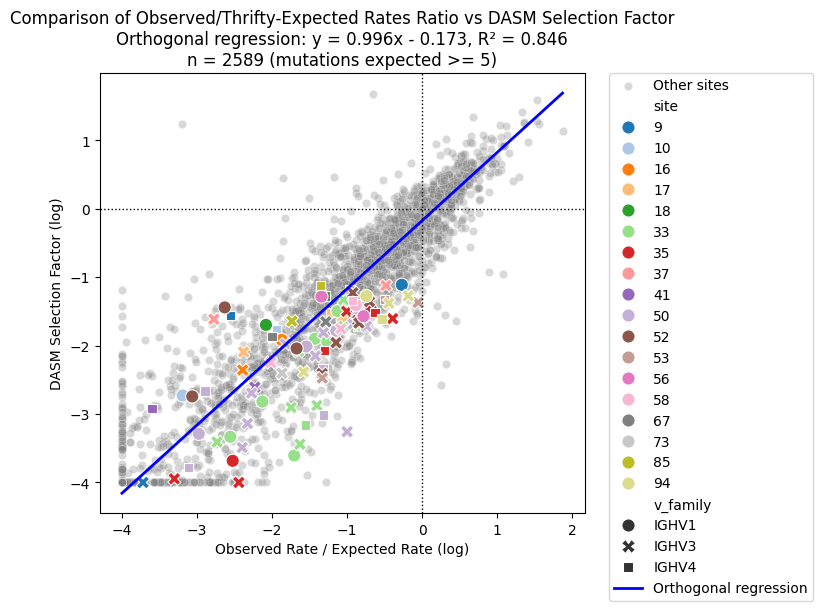

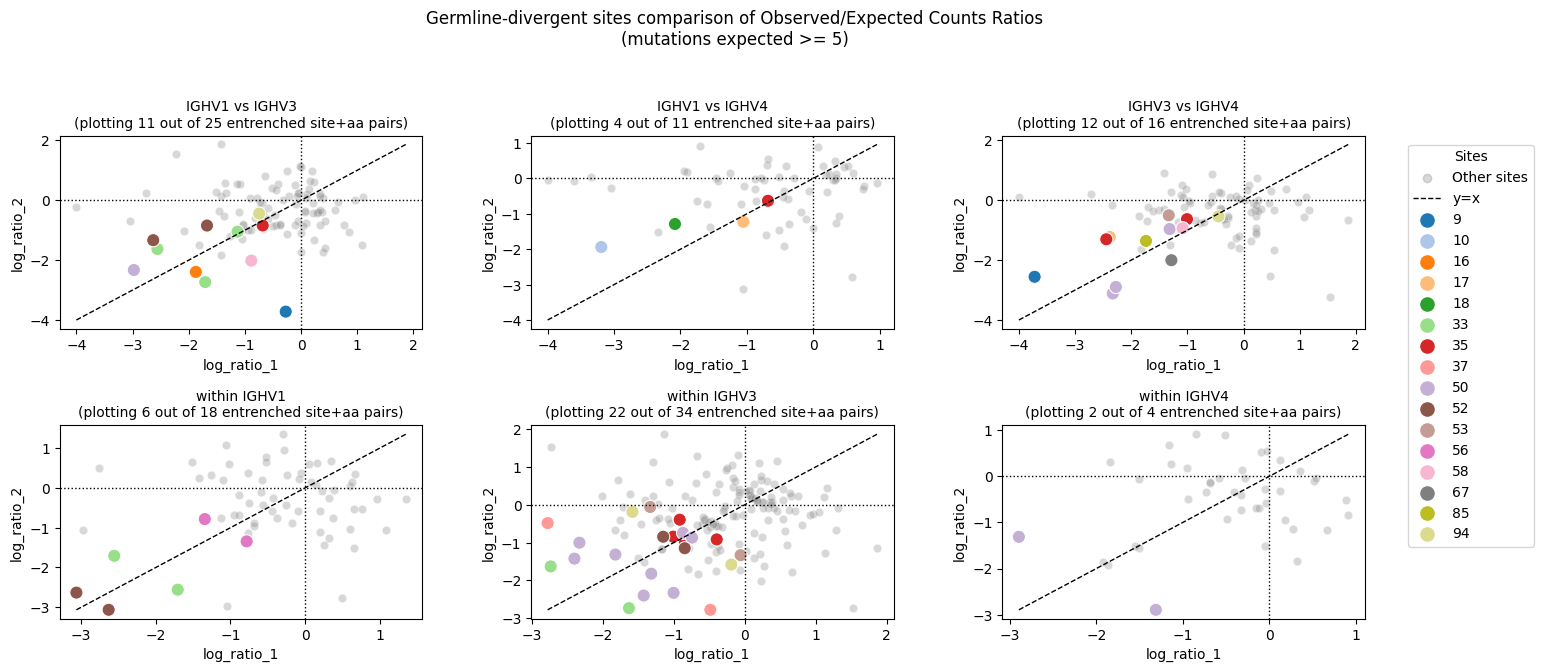

In [12]:
# show filtered data

compare_dasm_rates = pd.merge(merge_counts, dasm_summarized.rename(columns={'selection_factor_target_aa':'child_aa'}), on=['v_family', 'site', 'parent_aa', 'child_aa'], suffixes=('_rates', '_dasm'))
compare_dasm_rates['log_selection_factor'] = np.log(compare_dasm_rates['selection_factor'])

# clip very low and very high values
compare_dasm_rates['log_selection_factor'] = compare_dasm_rates['log_selection_factor'].clip(lower=-4, upper=2)
compare_dasm_rates['log_ratio'] = compare_dasm_rates['log_ratio'].clip(lower=-4, upper=2)

compare_dasm_rates = compare_dasm_rates[compare_dasm_rates.expected_counts >= 5]

plot_dasm_vs_rates_comparison(compare_dasm_rates, entrenched_sites_aas, SITE_COLOR_MAP, 
                              savefig_prefix='jaffe_rates_w_thrifty_', 
                              title="Comparison of Observed/Thrifty-Expected Rates Ratio vs DASM Selection Factor",
                              title_extra='(mutations expected >= 5)')

plot_rates_pairwise_analysis(compare_dasm_rates, pairwise_df_dict, SITE_COLOR_MAP, 
                             savefig_prefix='jaffe_rates_w_thrifty_', title_extra='(mutations expected >= 5)')

## Validation: Synonymous vs Non-synonymous Mutations

Test that synonymous mutations have log count ratios centered around 0 (neutral), while non-synonymous mutations show a broader distribution with more negative values (purifying selection).

This analysis uses codon-level counts to separate synonymous from non-synonymous changes.

In [13]:
# Filter expected data to exclude leaves (to match observed):
pcp_indices_non_leaf = neutral_probabilties.pcp_df[~neutral_probabilties.pcp_df['child_is_leaf']].index
# Get codon-level expected counts from Thrifty
expected_codon_df = neutral_probabilties.codon_neutral_df[
    (neutral_probabilties.codon_neutral_df.is_germline_codon == True) & 
    (neutral_probabilties.codon_neutral_df.pcp_index.isin(pcp_indices_non_leaf))
].groupby(['site', 'current_codon', 'v_family', 'transition_codon']).substitution_probability.sum().reset_index()


expected_codon_df = expected_codon_df.rename(columns={
    'current_codon': 'parent_codon', 
    'transition_codon': 'child_codon', 
    'substitution_probability': 'expected_counts'
})

# Add parent_aa and child_aa columns
from Bio.Seq import Seq

expected_codon_df['parent_aa'] = expected_codon_df['parent_codon'].apply(
    lambda x: str(Seq(x).translate()) if len(x) == 3 else 'X'
)
expected_codon_df['child_aa'] = expected_codon_df['child_codon'].apply(
    lambda x: str(Seq(x).translate()) if len(x) == 3 else 'X'
)

expected_codon_df

,site,parent_codon,v_family,child_codon,expected_counts,parent_aa,child_aa
0,1,CAA,IGHV1,AAA,0.191227,Q,K
1,1,CAA,IGHV1,CAC,0.568248,Q,H
2,1,CAA,IGHV1,CAG,0.661537,Q,Q
3,1,CAA,IGHV1,CAT,0.530767,Q,H
4,1,CAA,IGHV1,CCA,0.436487,Q,P
...,...,...,...,...,...,...,...
10138,94,GCA,IGHV1,GCG,0.433536,A,A
10139,94,GCA,IGHV1,GCT,0.185576,A,A
10140,94,GCA,IGHV1,GGA,0.191461,A,G
10141,94,GCA,IGHV1,GTA,0.188725,A,V


In [14]:
# Load observed codon-level counts
observed_codon_df = pd.read_csv(f'{output_base_path}_per_codon_mutation_rates.csv', dtype={'site':str})
observed_codon_df = observed_codon_df.rename(
    columns={
        'mutation_acquired': 'observed_counts',
        'mutation_acquired_adjusted': 'observed_counts_adjusted'
    }
).drop(columns=['rate_mutcount', 'rate_mutcount_adjusted', 'mutcount_length'])

# Merge observed and expected codon counts
merge_codon_counts = pd.merge(
    expected_codon_df,
    observed_codon_df, 
    on=['v_family', 'site', 'parent_codon', 'child_codon', 'parent_aa', 'child_aa'],
    how='inner'
)

# Use adjusted counts (with pseudocount already applied to observed)
# For expected counts from Thrifty, we add pseudocount here since Thrifty doesn't have it built in
pseudocount = 0.5
merge_codon_counts['ratio'] = merge_codon_counts['observed_counts_adjusted'] / (merge_codon_counts['expected_counts'] + pseudocount)
merge_codon_counts['log_ratio'] = np.log(merge_codon_counts['ratio'])

merge_codon_counts

,site,parent_codon,v_family,child_codon,expected_counts,parent_aa,child_aa,observed_counts,observed_counts_adjusted,ratio,log_ratio
0,1,CAA,IGHV1,AAA,0.191227,Q,K,0,0.5,0.723351,-0.323860
1,1,CAA,IGHV1,CAC,0.568248,Q,H,0,0.5,0.468056,-0.759167
2,1,CAA,IGHV1,CAG,0.661537,Q,Q,0,0.5,0.430464,-0.842891
3,1,CAA,IGHV1,CAT,0.530767,Q,H,0,0.5,0.485076,-0.723450
4,1,CAA,IGHV1,CCA,0.436487,Q,P,0,0.5,0.533910,-0.627528
...,...,...,...,...,...,...,...,...,...,...,...
6151,94,GCA,IGHV1,GCG,0.433536,A,A,1,1.5,1.606795,0.474241
6152,94,GCA,IGHV1,GCT,0.185576,A,A,1,1.5,2.187941,0.782961
6153,94,GCA,IGHV1,GGA,0.191461,A,G,0,0.5,0.723107,-0.324198
6154,94,GCA,IGHV1,GTA,0.188725,A,V,0,0.5,0.725980,-0.320233


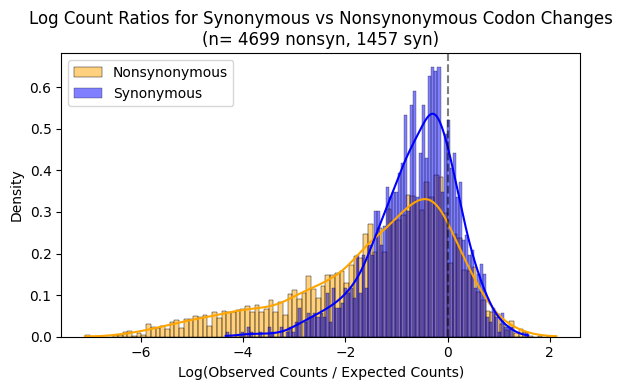

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))

# Filter data
nonsynonymous = merge_codon_counts[
    merge_codon_counts.parent_aa != merge_codon_counts.child_aa
].log_ratio

synonymous = merge_codon_counts[
    merge_codon_counts.parent_aa == merge_codon_counts.child_aa
].log_ratio

sns.histplot(nonsynonymous, ax=ax, label='Nonsynonymous', kde=True, stat='density', alpha=0.5, bins=100, color='orange')
sns.histplot(synonymous, ax=ax, label='Synonymous', kde=True, stat='density', alpha=0.5, bins=100, color='blue')

ax.legend()
ax.set_xlabel('Log(Observed Counts / Expected Counts)')
ax.set_title('Log Count Ratios for Synonymous vs Nonsynonymous Codon Changes\n(n= {} nonsyn, {} syn)'.format(len(nonsynonymous), len(synonymous)))
ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='Neutral (ratio=1)')
plt.tight_layout()
plt.show()

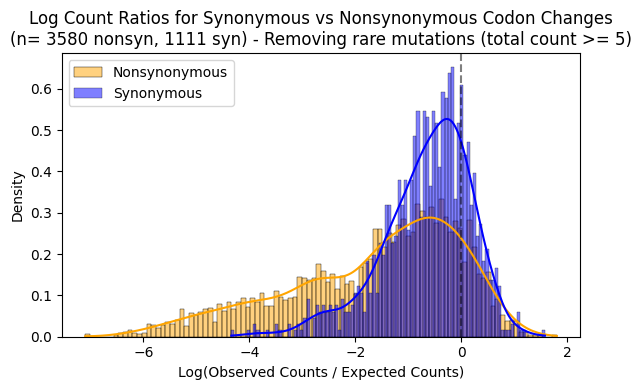


Summary statistics (filtered data):
Synonymous mutations - Mean log ratio: -0.661, Median: -0.530
Nonsynonymous mutations - Mean log ratio: -1.645, Median: -1.283


In [16]:
fig, ax = plt.subplots(figsize=(6, 4))

# Filter data - remove rare mutations
min_count_threshold = 5

nonsynonymous = merge_codon_counts[
    (merge_codon_counts.parent_aa != merge_codon_counts.child_aa) &
    (merge_codon_counts['expected_counts'] >= min_count_threshold)
].log_ratio

synonymous = merge_codon_counts[
    (merge_codon_counts.parent_aa == merge_codon_counts.child_aa) &
    (merge_codon_counts['expected_counts'] >= min_count_threshold)
].log_ratio

sns.histplot(nonsynonymous, ax=ax, label='Nonsynonymous', kde=True, stat='density', alpha=0.5, bins=100, color='orange')
sns.histplot(synonymous, ax=ax, label='Synonymous', kde=True, stat='density', alpha=0.5, bins=100, color='blue')

ax.legend()
ax.set_xlabel('Log(Observed Counts / Expected Counts)')
ax.set_title('Log Count Ratios for Synonymous vs Nonsynonymous Codon Changes\n(n= {} nonsyn, {} syn) - Removing rare mutations (total count >= {})'.format(
    len(nonsynonymous), len(synonymous), min_count_threshold))
ax.axvline(0, color='black', linestyle='--', alpha=0.5, label='Neutral (ratio=1)')
plt.tight_layout()
plt.show()

print(f"\nSummary statistics (filtered data):")
print(f"Synonymous mutations - Mean log ratio: {synonymous.mean():.3f}, Median: {synonymous.median():.3f}")
print(f"Nonsynonymous mutations - Mean log ratio: {nonsynonymous.mean():.3f}, Median: {nonsynonymous.median():.3f}")

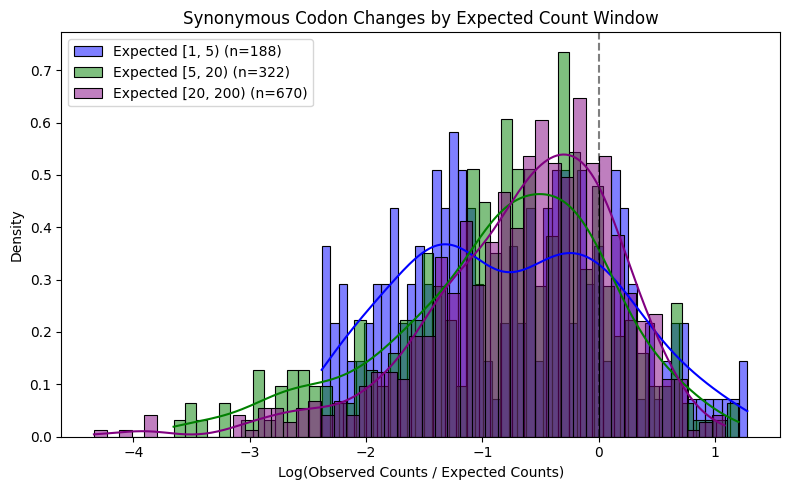

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))

# Define non-overlapping windows
windows = [(1, 5), (5, 20), (20, 200)]
colors = ['blue', 'green', 'purple']

for (low, high), color in zip(windows, colors):
    data = merge_codon_counts[
        (merge_codon_counts.parent_aa == merge_codon_counts.child_aa) &
        (merge_codon_counts['expected_counts'] >= low) &
        (merge_codon_counts['expected_counts'] < high)
    ].log_ratio
    
    sns.histplot(data, ax=ax, label=f'Expected [{low}, {high}) (n={len(data)})', 
                 kde=True, stat='density', alpha=0.5, bins=50, color=color)

ax.legend()
ax.set_xlabel('Log(Observed Counts / Expected Counts)')
ax.set_title('Synonymous Codon Changes by Expected Count Window')
ax.axvline(0, color='black', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()